<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 157.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 193.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 133.8 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


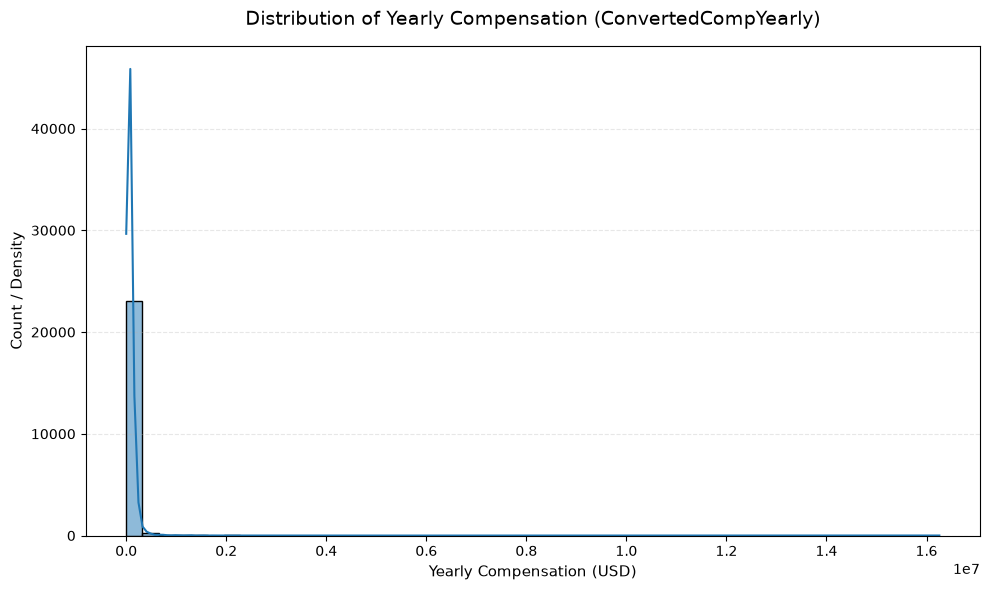

In [3]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop missing compensation values to get a clean visual sample
df_comp_dist = df.dropna(subset=['ConvertedCompYearly']).copy()

# 2. Plot the histogram combined with a kernel density estimate (KDE) line
plt.figure(figsize=(10, 6))
sns.histplot(data=df_comp_dist, x='ConvertedCompYearly', kde=True, color='#1f77b4', bins=50)

plt.title('Distribution of Yearly Compensation (ConvertedCompYearly)', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation (USD)', fontsize=11)
plt.ylabel('Count / Density', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
## Write your code here
# 1. Filter the dataset for full-time employees
df_full_time = df[df['Employment'] == 'Employed, full-time']

# 2. Calculate the median yearly compensation for this group
median_ft_comp = df_full_time['ConvertedCompYearly'].median()

print("=== Full-Time Employee Compensation Analysis ===")
print(f"Number of full-time respondents: {len(df_full_time):,}")
print(f"Median Yearly Compensation:       ${median_ft_comp:,.2f}")

=== Full-Time Employee Compensation Analysis ===
Number of full-time respondents: 39,041
Median Yearly Compensation:       $69,814.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



=== Top 5 Countries Sample Sizes ===
Country
United States of America                                4677
Germany                                                 2046
Ukraine                                                 1474
United Kingdom of Great Britain and Northern Ireland    1391
India                                                   1037
Name: count, dtype: int64


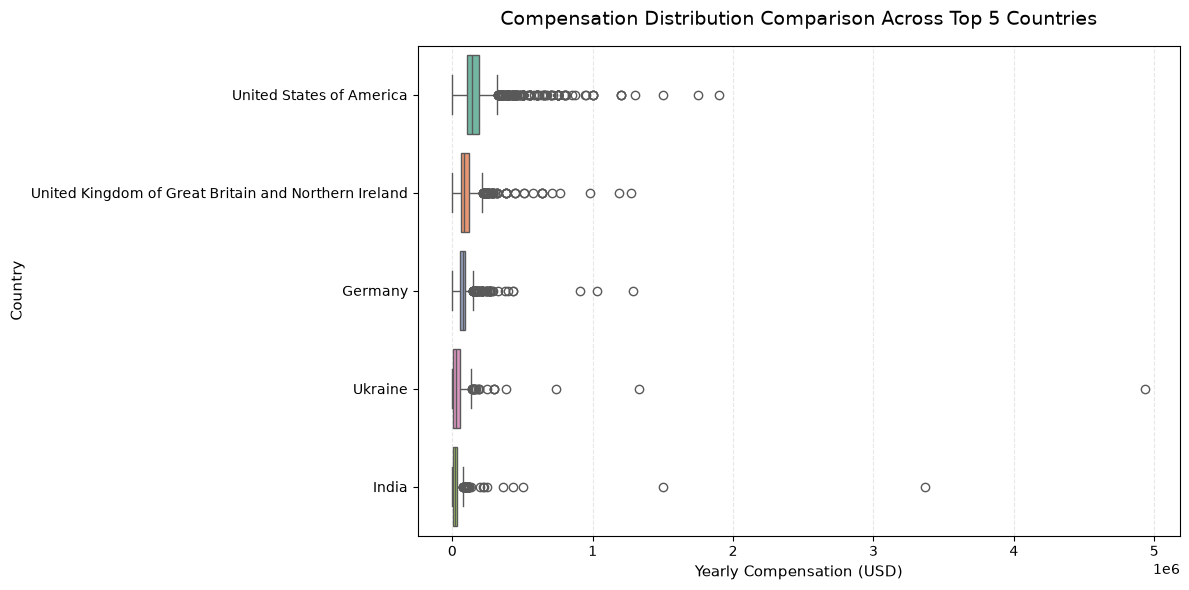

In [5]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop missing compensation and country values
df_country = df.dropna(subset=['ConvertedCompYearly', 'Country']).copy()

# 2. Identify the Top 5 countries by number of respondents
top_countries = df_country['Country'].value_counts().nlargest(5).index
df_top_countries = df_country[df_country['Country'].isin(top_countries)]

print("=== Top 5 Countries Sample Sizes ===")
print(df_country['Country'].value_counts().loc[top_countries])

# 3. Plot box plots for the top countries to compare distributions
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top_countries, 
    x='ConvertedCompYearly', 
    y='Country', 
    hue='Country',
    palette='Set2',
    legend=False
)

plt.title('Compensation Distribution Comparison Across Top 5 Countries', fontsize=14, pad=15)
plt.xlabel('Yearly Compensation (USD)', fontsize=11)
plt.ylabel('Country', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [6]:
## Write your code here
import pandas as pd

# 1. Drop missing compensation values to isolate our target data
df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

# 2. Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
Q1 = df_clean['ConvertedCompYearly'].quantile(0.25)
Q3 = df_clean['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 3. Define the outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the data to keep only records within the IQR bounds
df_no_outliers = df_clean[(df_clean['ConvertedCompYearly'] >= lower_bound) & (df_clean['ConvertedCompYearly'] <= upper_bound)].copy()

print("=== Outlier Removal Summary ===")
print(f"Original Row Count: {len(df_clean):,}")
print(f"Refined Row Count:  {len(df_no_outliers):,}")
print(f"Outliers Removed:   {len(df_clean) - len(df_no_outliers):,}")

=== Outlier Removal Summary ===
Original Row Count: 23,435
Refined Row Count:  22,457
Outliers Removed:   978


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


=== Correlation Matrix ===
                     ConvertedCompYearly  WorkExp  JobSatPoints_1
ConvertedCompYearly               1.0000   0.4084         -0.0582
WorkExp                           0.4084   1.0000         -0.0324
JobSatPoints_1                   -0.0582  -0.0324          1.0000

Generating correlation heatmap...


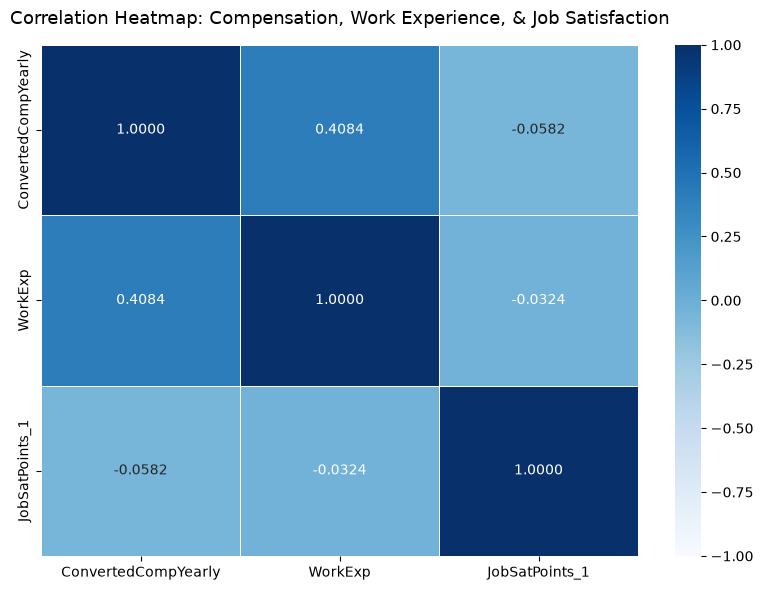

In [7]:
## Write your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure columns are treated as numeric for calculation
df_no_outliers['WorkExp'] = pd.to_numeric(df_no_outliers['WorkExp'], errors='coerce')
df_no_outliers['JobSatPoints_1'] = pd.to_numeric(df_no_outliers['JobSatPoints_1'], errors='coerce')

# 2. Select the specific columns for correlation analysis
target_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
corr_matrix = df_no_outliers[target_cols].corr()

print("=== Correlation Matrix ===")
print(corr_matrix.round(4))
print("\nGenerating correlation heatmap...")

# 3. Visualize the matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='Blues', 
    fmt=".4f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title('Correlation Heatmap: Compensation, Work Experience, & Job Satisfaction', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


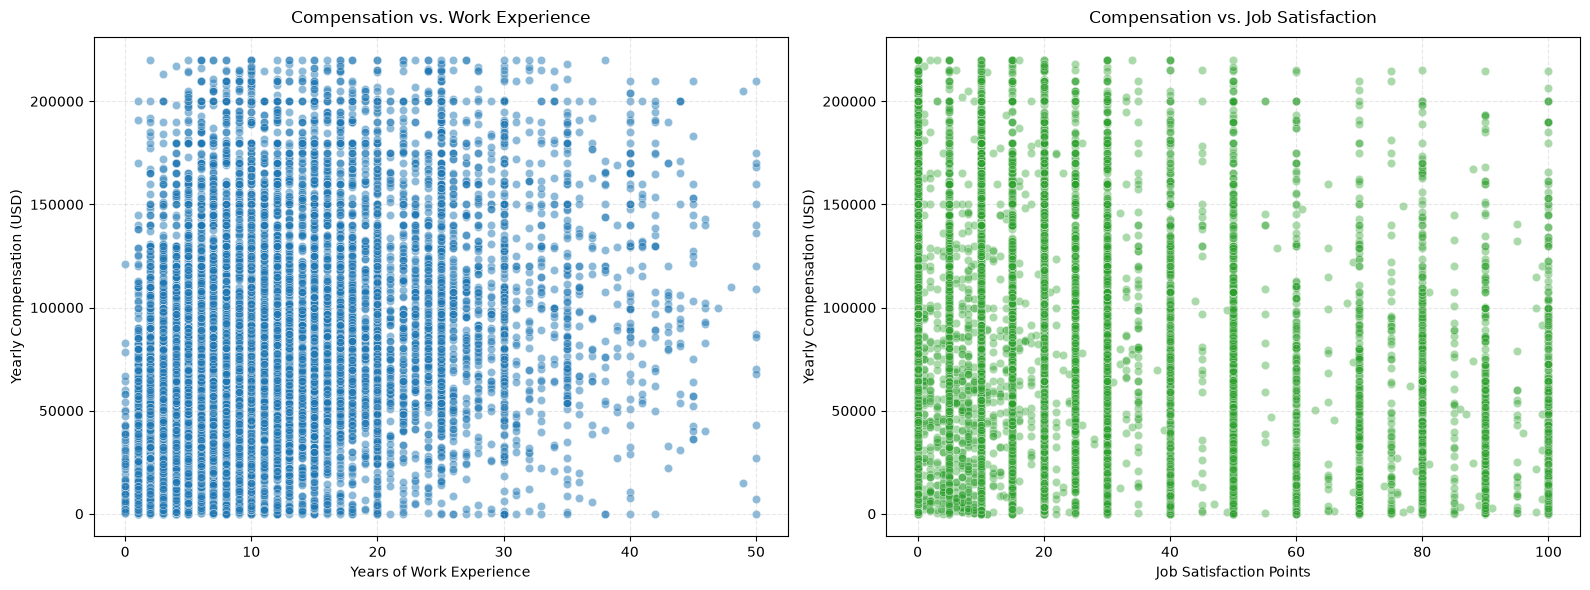

In [8]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a side-by-side plotting area
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter Plot: Compensation vs Work Experience
sns.scatterplot(
    data=df_no_outliers, 
    x='WorkExp', 
    y='ConvertedCompYearly', 
    ax=axes[0], 
    alpha=0.5, 
    color='#1f77b4'
)
axes[0].set_title('Compensation vs. Work Experience', fontsize=12, pad=10)
axes[0].set_xlabel('Years of Work Experience', fontsize=10)
axes[0].set_ylabel('Yearly Compensation (USD)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2. Scatter Plot: Compensation vs Job Satisfaction Points
sns.scatterplot(
    data=df_no_outliers, 
    x='JobSatPoints_1', 
    y='ConvertedCompYearly', 
    ax=axes[1], 
    alpha=0.4, 
    color='#2ca02c'
)
axes[1].set_title('Compensation vs. Job Satisfaction', fontsize=12, pad=10)
axes[1].set_xlabel('Job Satisfaction Points', fontsize=10)
axes[1].set_ylabel('Yearly Compensation (USD)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
